# 09. Pretrained CNN Models

This notebook studies six influential CNN families. Focus on why each design was introduced, not on memorizing every layer.

Architectures: AlexNet, VGG, ResNet, DenseNet, MobileNet, and EfficientNet.

The practical example reads a sample from this project's existing CIFAR-10 files in data/cifar-10-batches-py. It does not download another dataset.

## 1. The local dataset used in this project

The project already contains CIFAR-10 in data/cifar-10-batches-py. CIFAR-10 has 32x32 RGB images in 10 classes. We use these images for the sample visualization below. Model parameter counts are inspected without loading pretrained weights or downloading data.

Local CIFAR-10 test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


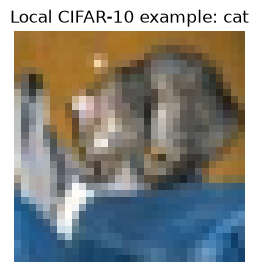

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
DATA_ROOT = Path("data")
CIFAR_DIR = DATA_ROOT / "cifar-10-batches-py"
if not CIFAR_DIR.is_dir():
    raise FileNotFoundError(f"Expected existing local CIFAR-10 files at {CIFAR_DIR.resolve()}")
cifar_test = CIFAR10(root=str(DATA_ROOT), train=False, download=False)
class_names = cifar_test.classes
print(f"Local CIFAR-10 test images: {len(cifar_test)}")
print(f"Classes: {class_names}")
image, label = cifar_test[0]
plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.title(f"Local CIFAR-10 example: {class_names[label]}")
plt.axis("off")
plt.show()

## 2. AlexNet

**Basic idea:** Show that a deep CNN trained on a large image collection can greatly improve image classification.

**Characteristics:** Convolution and pooling stages; ReLU activations; dropout in the classifier; designed for large-scale ImageNet images.

**Major innovation / why it was designed:** AlexNet's ImageNet success in 2012 demonstrated the effectiveness of deep CNNs at scale, aided by GPUs, ReLU, and data augmentation.

**Advantages:** Historically important; straightforward to study; established deep learning as a strong vision approach.

**Limitations:** Large fully connected layers and high compute/memory needs compared with modern compact models.

**Typical uses:** Education, historical baselines, and understanding the transition to modern CNNs.

## 3. VGG

**Basic idea:** Build depth using a simple, repeated pattern of small 3x3 convolutions.

**Characteristics:** Regular stacks of convolutions and pooling; VGG16 and VGG19 are common variants.

**Major innovation / why it was designed:** Repeated small filters provide a systematic way to increase depth and receptive field while keeping the design easy to understand.

**Advantages:** Simple architecture; useful feature representations; clear teaching and transfer-learning example.

**Limitations:** Very large parameter count, memory footprint, and compute cost, especially in the classifier.

**Typical uses:** Feature extraction, historical comparisons, and educational baselines when resources allow.

## 4. ResNet

**Basic idea:** Make very deep networks easier to optimize using residual (skip) connections.

**Characteristics:** Residual blocks add a block's input to its transformed output. Common models include ResNet18, ResNet50, and deeper variants.

**Major innovation / why it was designed:** A block can learn a residual adjustment instead of having to learn a complete transformation. The identity path gives information and gradients a direct route through the network.

**Advantages:** Reliable training at depth; strong accuracy; widely supported as a general-purpose backbone and pretrained model.

**Limitations:** Larger variants can be computationally expensive and are heavier than mobile-focused networks.

**Typical uses:** Classification, transfer learning, and backbones for detection or segmentation.

## 5. DenseNet

**Basic idea:** Reuse earlier features by connecting each layer to later layers within a dense block.

**Characteristics:** Later layers receive concatenated feature maps from preceding layers; transition layers reduce spatial size and channel count.

**Major innovation / why it was designed:** Dense connectivity encourages feature reuse and improves information and gradient flow, reducing redundant relearning.

**Advantages:** Good feature reuse; can be parameter-efficient for its accuracy; strong image representations.

**Limitations:** Concatenated activations can consume substantial memory and complicate deployment.

**Typical uses:** Classification and feature-extraction research where memory allows.

## 6. MobileNet

**Basic idea:** Make useful CNNs practical on phones and other compute-limited devices.

**Characteristics:** Uses depthwise-separable convolutions, which factor a standard convolution into spatial filtering per channel and a 1x1 channel-mixing operation. MobileNet versions add further efficiency improvements.

**Major innovation / why it was designed:** Reduce multiply-add operations and model size while retaining useful visual features.

**Advantages:** Small and fast; suited to edge inference and latency or memory constraints.

**Limitations:** The accuracy-versus-size trade-off may be unfavorable when maximum accuracy is the only goal; hardware affects real speed.

**Typical uses:** Mobile apps, embedded cameras, and real-time edge vision.

## 7. EfficientNet

**Basic idea:** Scale a model in a balanced way rather than increasing only depth, width, or image resolution.

**Characteristics:** Compound scaling adjusts all three dimensions together across model sizes.

**Major innovation / why it was designed:** A principled scaling rule aims to get more accuracy from a given compute budget.

**Advantages:** Strong accuracy-efficiency trade-off; a family of sizes can fit different resource limits.

**Limitations:** Larger variants still need significant compute; deployment speed depends on hardware and implementation.

**Typical uses:** Classification and transfer-learning pipelines needing a balance of accuracy and efficiency.

## 8. Compare the design goals

| Model | Design problem it targeted | Main idea | Typical trade-off |
|---|---|---|---|
| AlexNet | Could deep CNNs win large-scale vision tasks? | Train a CNN at ImageNet scale | Breakthrough accuracy, but heavy by today's standards |
| VGG | How can depth be increased with a regular design? | Stack small convolutions | Simple features, high parameter and compute cost |
| ResNet | How can very deep networks remain trainable? | Residual skip connections | Strong general backbone, deeper versions cost more |
| DenseNet | Can layers reuse features instead of relearning them? | Dense feature connections | Feature reuse, potentially high activation memory |
| MobileNet | How can CNNs fit edge hardware? | Efficient separable convolutions | Lower latency/size, possible accuracy trade-off |
| EfficientNet | How can a model scale efficiently? | Compound depth/width/resolution scaling | Strong efficiency, variants still need benchmarking |

## 9. Inspect TorchVision model sizes

The cell below instantiates architectures with no pretrained weights and reports parameter counts. It does not fetch model weights or any dataset. Parameter count alone does not measure actual latency.

In [3]:
from torchvision import models
torchvision_models = {
    "AlexNet": models.alexnet,
    "VGG16": models.vgg16,
    "ResNet18": models.resnet18,
    "DenseNet121": models.densenet121,
    "MobileNetV2": models.mobilenet_v2,
    "EfficientNet-B0": models.efficientnet_b0,
}
for name, model_factory in torchvision_models.items():
    model = model_factory(weights=None)
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    print(f"{name:16s} {parameter_count:>12,} parameters")
    del model

AlexNet            61,100,840 parameters
VGG16             138,357,544 parameters
ResNet18           11,689,512 parameters
DenseNet121         7,978,856 parameters
MobileNetV2         3,504,872 parameters
EfficientNet-B0     5,288,548 parameters


## 10. Final takeaway

Choose an architecture based on the problem it was designed to solve: depth and stable optimization (ResNet), feature reuse (DenseNet), or constrained inference (MobileNet). Validate the choice on the task's own data—in this project, the available dataset is local CIFAR-10—not on assumptions from architecture names alone.